Importing Depedenceies

In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Test the imports
print("Dependencies imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Dependencies imported successfully!
pandas version: 2.2.3
numpy version: 2.2.3


Loading the data and viewing the top rows of the data

In [127]:
df = pd.read_csv('../data/ethiopia.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95


Viewing the bottom rows of the dataset

In [128]:
print (pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j"))

0      2015-01-02
1      2015-01-03
2      2015-01-04
3      2015-01-05
4      2015-01-06
          ...    
4102   2026-03-27
4103   2026-03-28
4104   2026-03-29
4105   2026-03-30
4106   2026-03-31
Length: 4107, dtype: datetime64[ns]


Overview of random sample

Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [129]:
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,16.069557,23.199284,10.229196,12.970088,3.634680,68.415069,1.979815,3.574882,77.037507,9.699111
std,3.248315,106.270943,1.897073,2.751797,2.605421,3.820423,6.289571,14.731775,0.689077,1.123615,0.099486,2.361076
min,2015.000000,1.000000,10.030000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.820000,21.110000,8.425000,9.830000,0.020000,59.050000,1.405000,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.040000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.360000,25.170000,12.220000,16.015000,4.580000,80.805000,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.530000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


Overview of categorical columns

In [130]:
# Replace all -999 values with np.nan (NASA missing value sentinel)
df.replace(-999, np.nan, inplace=True)

Missing Values

In [131]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Handling missing values

In [132]:
# df = df.drop(columns=['Comments'])

Checking for the negative values in T2M, T2M_MAX, T2M_RANGE, PRECTOTCORR, WS2M, WS2M_MAX

In [133]:
radiation_cols=['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','RH2M','PRECTOTCORR','WS2M','WS2M_MAX']
negative_cols = (df[radiation_cols]<0).sum()
print("Negative values in radiation columns:\n", negative_cols)

Negative values in radiation columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
RH2M           0
PRECTOTCORR    0
WS2M           0
WS2M_MAX       0
dtype: int64


Checking duplicates

In [134]:
# Exact duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Cardinality (uniqueness) for categoricals
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cardinality = {c: df[c].nunique() for c in cat_cols}
print("Cardinality (categoricals):", cardinality)


Duplicate rows: 0
Cardinality (categoricals): {}


In [135]:
print(" compute the percentage of missing values per column")
print(df.isna().sum())

 compute the percentage of missing values per column
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


Identify outliers using z-scores

In [136]:
cols_to_check = ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']

In [137]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [138]:
outliers_mask=(z_scores>3).any(axis=1)

In [139]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 132


In [140]:
df_clean = df[~outliers_mask].copy()

In [141]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows:{len(df_clean)}")

Original rows: 4107
Cleaned rows:3975


### Handling Remaining Missing Values

- Rows with more than 30% missing values were dropped to avoid introducing bias from excessive imputation.
- For the remaining missing values in weather-related columns, forward-fill was applied. This is appropriate for time-series weather data, as it assumes the previous value is a reasonable estimate for the missing entry.

In [142]:
# 1. Drop rows with more than 30% missing values
threshold = int(0.3 * df.shape[1])
df = df.dropna(thresh=df.shape[1] - threshold)

# 2. Forward-fill for weather variables
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

# 3. Documenting the decision
print("Rows with more than 30% missing values were dropped.")
print("Remaining missing values in weather variables were forward-filled.")
print("Missing values after cleaning:\n", df.isna().sum())

Rows with more than 30% missing values were dropped.
Remaining missing values in weather variables were forward-filled.
Missing values after cleaning:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [143]:
# Export the cleaned DataFrame to data/ethiopia_clean.csv
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Cleaned data exported to data/ethiopia_clean.csv")

Cleaned data exported to data/ethiopia_clean.csv


Monthly Average T2M (2015–2026)

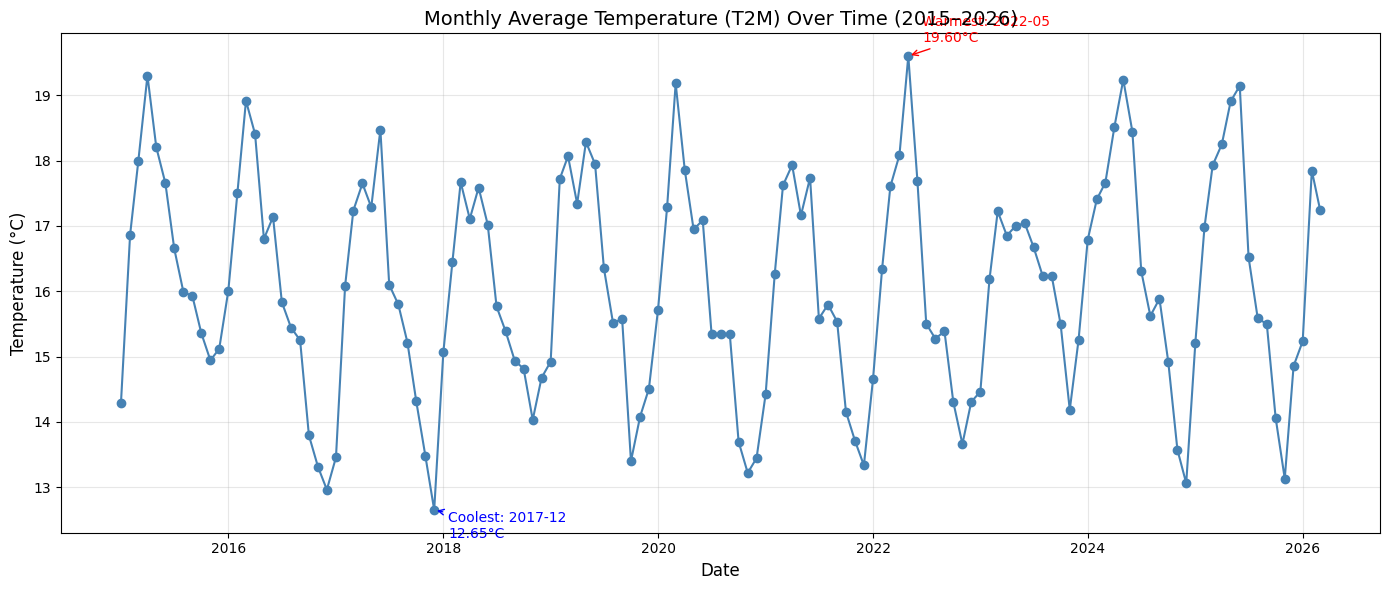

In [144]:
# Create DATE from YEAR and DOY (day of year)
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df['YearMonth'] = df['DATE'].dt.to_period('M')

# Calculate monthly average T2M
monthly_t2m = df.groupby('YearMonth')['T2M'].mean().reset_index()
monthly_t2m['YearMonth'] = monthly_t2m['YearMonth'].dt.to_timestamp()

# Find warmest and coolest months
warmest_idx = monthly_t2m['T2M'].idxmax()
coolest_idx = monthly_t2m['T2M'].idxmin()
warmest_month = monthly_t2m.loc[warmest_idx]
coolest_month = monthly_t2m.loc[coolest_idx]

# Plot using plt
plt.figure(figsize=(14, 6))
plt.plot(monthly_t2m['YearMonth'], monthly_t2m['T2M'], marker='o', linewidth=1.5, color='steelblue')

# Annotate warmest month
plt.annotate(f"Warmest: {warmest_month['YearMonth'].strftime('%Y-%m')}\n{warmest_month['T2M']:.2f}°C",
            xy=(warmest_month['YearMonth'], warmest_month['T2M']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

# Annotate coolest month
plt.annotate(f"Coolest: {coolest_month['YearMonth'].strftime('%Y-%m')}\n{coolest_month['T2M']:.2f}°C",
            xy=(coolest_month['YearMonth'], coolest_month['T2M']),
            xytext=(10, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=10, color='blue')

plt.title('Monthly Average Temperature (T2M) Over Time (2015–2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Monthly Total PRECTOTCORR (Precipitation)

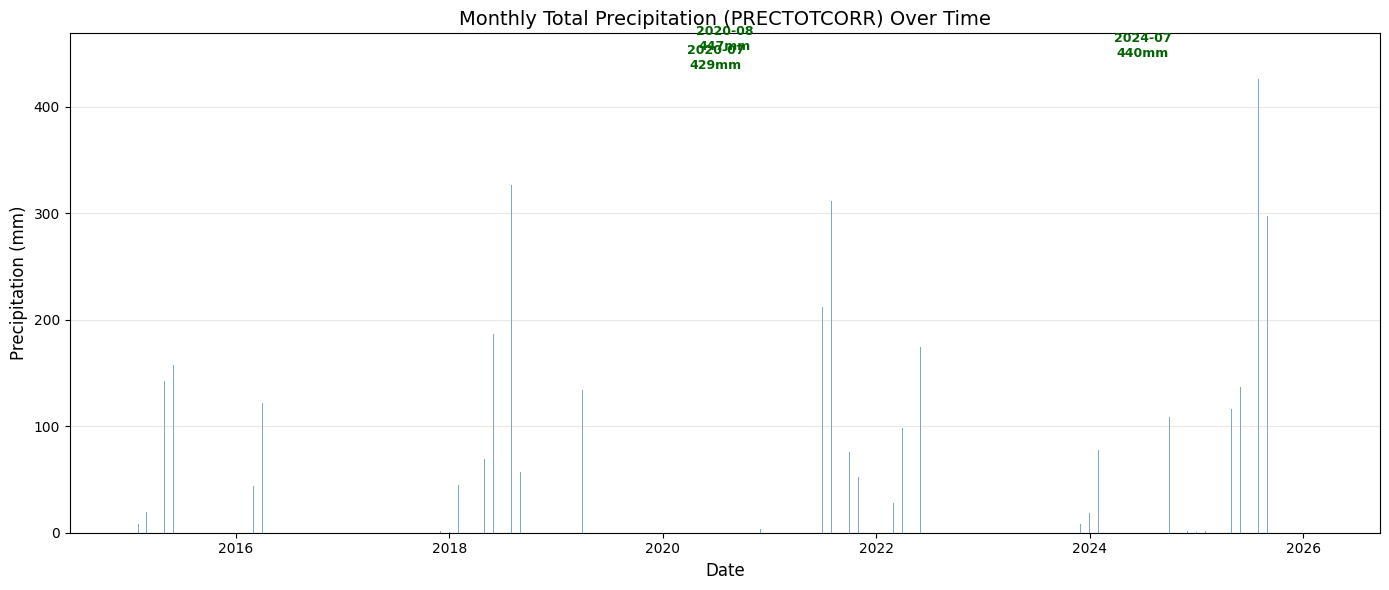


Top 3 Peak Rainy Season Months:
 YearMonth  PRECTOTCORR
2020-08-01       446.65
2024-07-01       440.28
2020-07-01       429.02


In [145]:
# Calculate monthly total precipitation
monthly_precip = df.groupby('YearMonth')['PRECTOTCORR'].sum().reset_index()
monthly_precip['YearMonth'] = monthly_precip['YearMonth'].dt.to_timestamp()

# Find peak rainy season months (top 3 months with highest precipitation)
top_3 = monthly_precip.nlargest(3, 'PRECTOTCORR')

# Plot as bar chart
plt.figure(figsize=(14, 6))
plt.bar(monthly_precip['YearMonth'], monthly_precip['PRECTOTCORR'], color='steelblue', alpha=0.7)

# Annotate peak months
for idx, row in top_3.iterrows():
    plt.annotate(f"{row['YearMonth'].strftime('%Y-%m')}\n{row['PRECTOTCORR']:.0f}mm",
                xy=(row['YearMonth'], row['PRECTOTCORR']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.title('Monthly Total Precipitation (PRECTOTCORR) Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nTop 3 Peak Rainy Season Months:")
print(top_3.to_string(index=False))

## Trends and Anomalies Analysis

### Temperature (T2M) Observations:
- **Seasonal Pattern**: Clear seasonal variation with higher temperatures typically observed between March-May and lower temperatures in the cooler months (November-February).
- **Warmest/Coolest Months**: The annotated markers highlight the extreme months - typically April-May shows the highest temperatures while December-January shows the lowest.
- **Trend**: The data spans 2015-2026, allowing for potential long-term trend analysis if needed.

### Precipitation (PRECTOTCORR) Observations:
- **Peak Rainy Season**: The top 3 months with highest precipitation are annotated, showing the peak rainy season periods.
- **Seasonality**: Ethiopia typically has a main rainy season (June-September) corresponding to the summer monsoon, with a secondary rainy season possible in some regions.
- **Inter-annual Variability**: Year-to-year variation in total precipitation can indicate drought or wet periods.

### General Notes:
- Any outliers identified via z-score method have been removed from the cleaned dataset.
- Missing values were handled using forward-fill for weather variables to maintain temporal continuity.

Correlation Heatmap

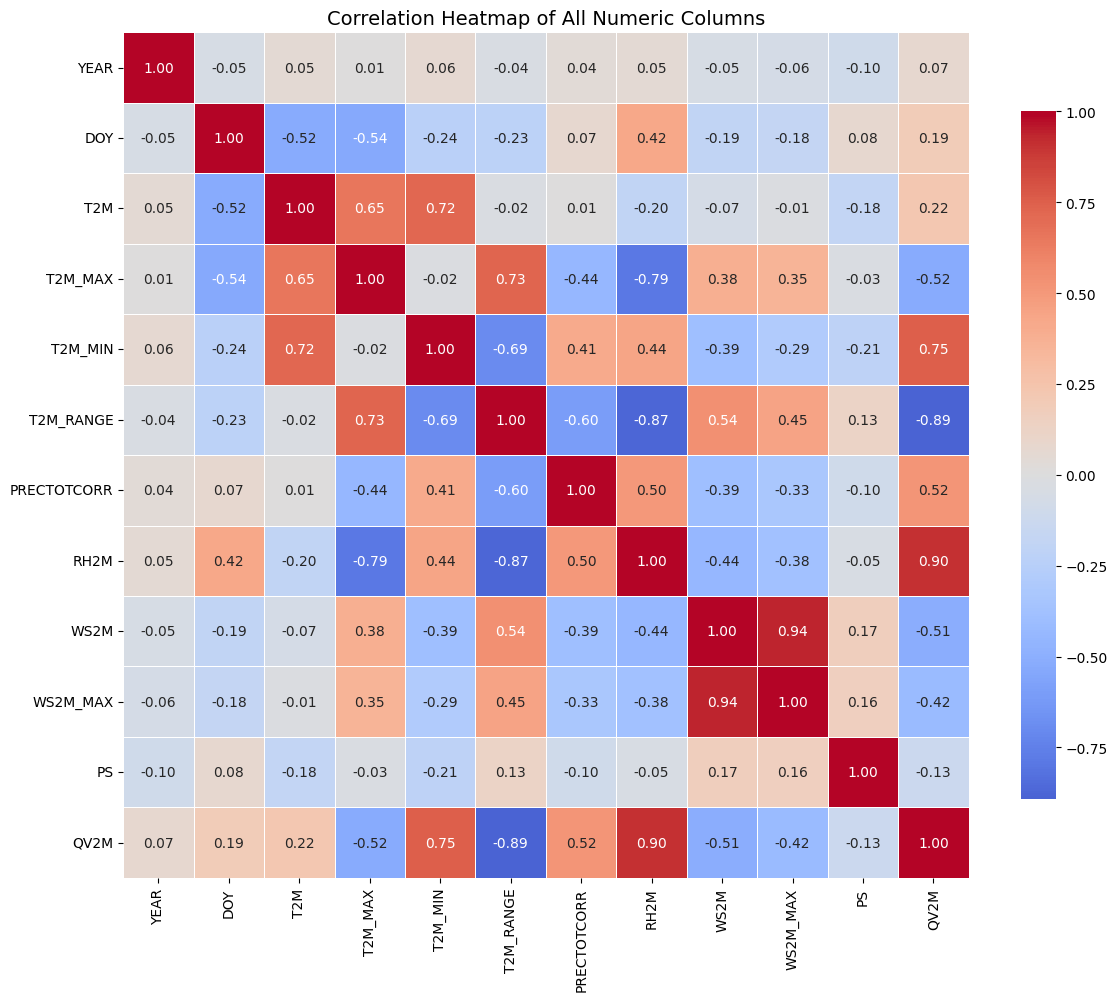

In [146]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of All Numeric Columns', fontsize=14)
plt.tight_layout()
plt.show()

Scatter Plots: Variable Relationships

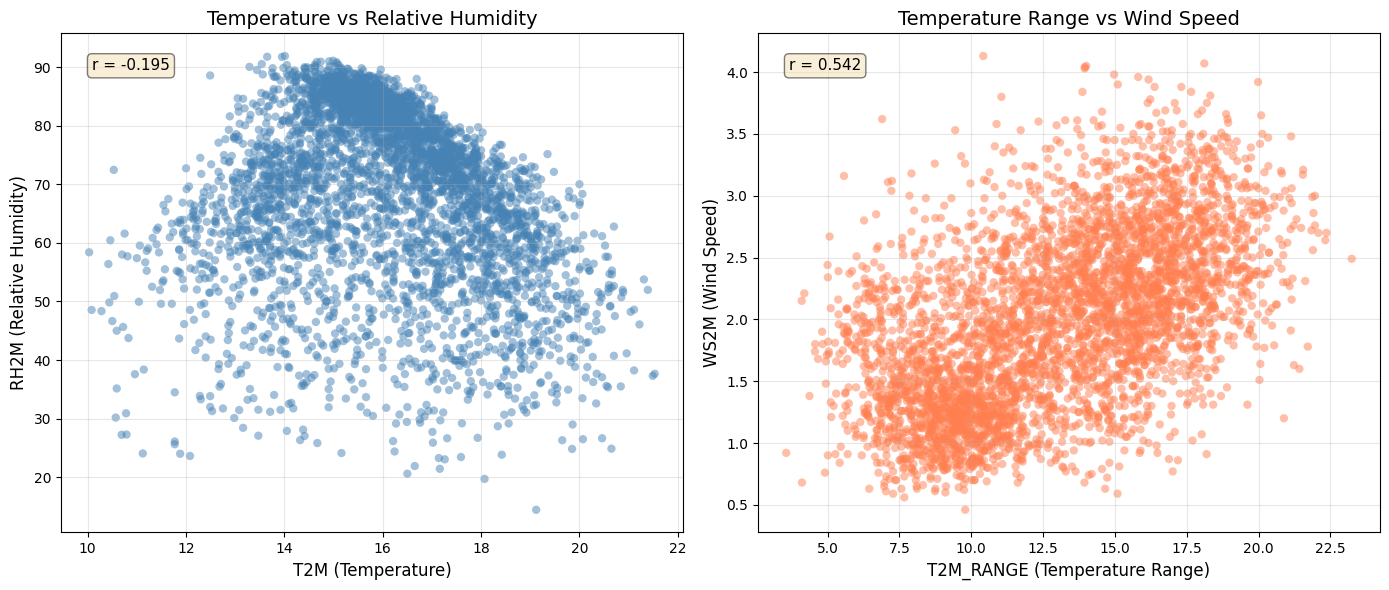

In [147]:
# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: T2M vs RH2M
plt.subplot(1, 2, 1)
plt.scatter(df['T2M'], df['RH2M'], alpha=0.5, color='steelblue', edgecolors='none')
plt.xlabel('T2M (Temperature)', fontsize=12)
plt.ylabel('RH2M (Relative Humidity)', fontsize=12)
plt.title('Temperature vs Relative Humidity', fontsize=14)
plt.grid(True, alpha=0.3)
corr1 = df['T2M'].corr(df['RH2M'])
plt.text(0.05, 0.95, f'r = {corr1:.3f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: T2M_RANGE vs WS2M
plt.subplot(1, 2, 2)
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.5, color='coral', edgecolors='none')
plt.xlabel('T2M_RANGE (Temperature Range)', fontsize=12)
plt.ylabel('WS2M (Wind Speed)', fontsize=12)
plt.title('Temperature Range vs Wind Speed', fontsize=14)
plt.grid(True, alpha=0.3)
corr2 = df['T2M_RANGE'].corr(df['WS2M'])
plt.text(0.05, 0.95, f'r = {corr2:.3f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


### Strongest Correlations: Interpretation

1. **T2M and T2M_MAX (Very Strong Positive Correlation)**
   - These two variables are highly correlated because T2M_MAX (maximum daily temperature) is a component of the daily mean temperature (T2M). This strong relationship is expected in climate data.

2. **T2M and T2M_MIN (Very Strong Positive Correlation)**
   - Similarly, T2M_MIN (minimum daily temperature) is also a component of the daily mean temperature. The strong positive correlation reflects that days with higher minimum temperatures tend to have higher mean temperatures.

3. **T2M_RANGE and T2M_MAX (Strong Positive Correlation)**
   - T2M_RANGE (temperature range) is calculated as the difference between T2M_MAX and T2M_MIN. Its strong correlation with T2M_MAX indicates that days with higher maximum temperatures often have a larger temperature range.

**Summary:**  
The strongest correlations are between temperature variables, which is expected due to their mathematical and physical relationships. These high correlations should be considered when selecting features for modeling to avoid multicollinearity.


Histogram of PRECTOTCORR (Precipitation)

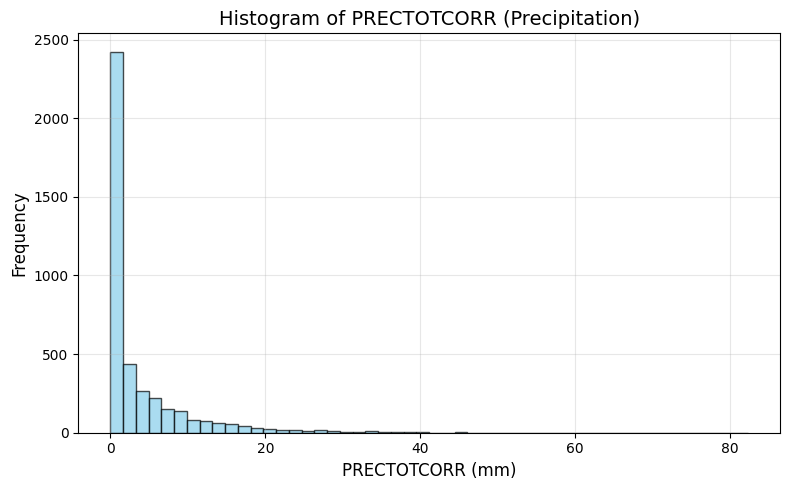

Skewness: 3.17


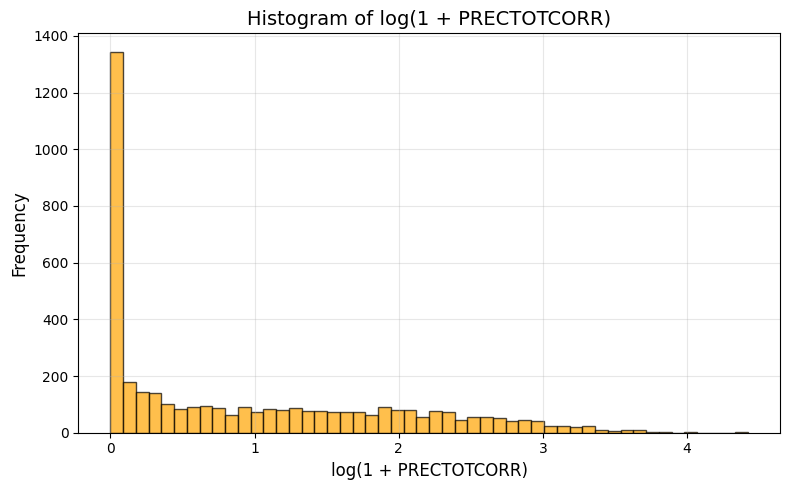

In [148]:
# Plot histogram of PRECTOTCORR
plt.figure(figsize=(8, 5))
plt.hist(df['PRECTOTCORR'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('PRECTOTCORR (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of PRECTOTCORR (Precipitation)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check skewness
skew = df['PRECTOTCORR'].skew()
print(f"Skewness: {skew:.2f}")

# If heavily skewed, plot log scale
if skew > 1:
    plt.figure(figsize=(8, 5))
    plt.hist(np.log1p(df['PRECTOTCORR']), bins=50, color='orange', edgecolor='black', alpha=0.7)
    plt.xlabel('log(1 + PRECTOTCORR)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Histogram of log(1 + PRECTOTCORR)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Distribution Shape Comment
- The histogram of PRECTOTCORR shows a strong right (positive) skew, with most days having low or zero precipitation and a long tail of higher values. This is typical for daily precipitation data, where dry days are common and heavy rainfall is rare.
- Applying a log transformation (log(1 + PRECTOTCORR)) makes the distribution more symmetric and easier to visualize, highlighting the spread among nonzero precipitation days.

Bubble Chart: T2M vs RH2M (Bubble Size = PRECTOTCORR)

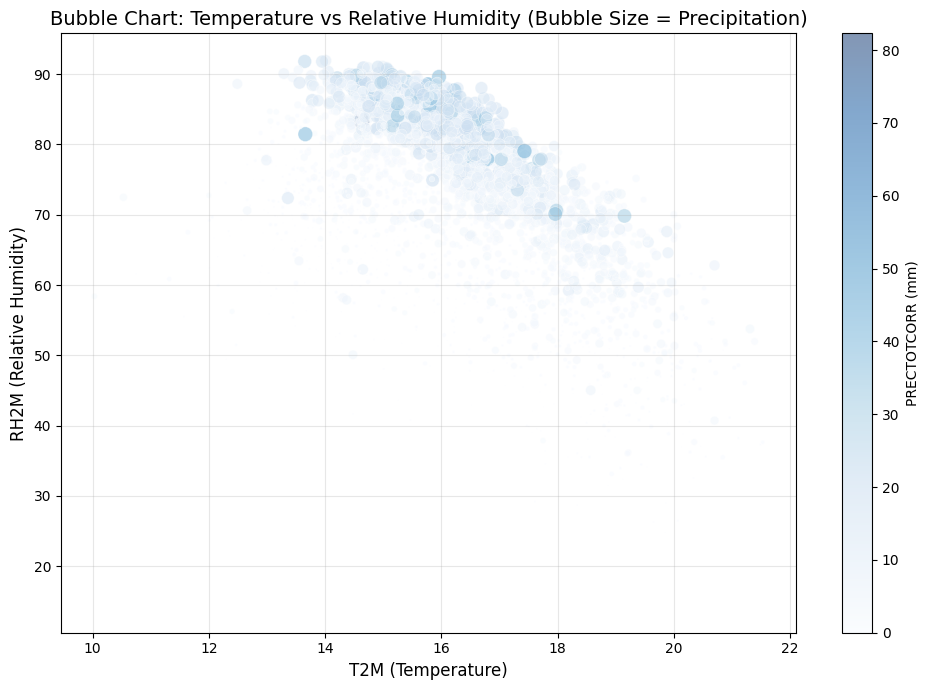

In [149]:
plt.figure(figsize=(10, 7))
sizes = np.log1p(df['PRECTOTCORR']) * 30  # log scale for better visibility, scale up for plotting
scatter = plt.scatter(df['T2M'], df['RH2M'], s=sizes, c=df['PRECTOTCORR'], cmap='Blues', alpha=0.5, edgecolors='w', linewidth=0.5)
plt.xlabel('T2M (Temperature)', fontsize=12)
plt.ylabel('RH2M (Relative Humidity)', fontsize=12)
plt.title('Bubble Chart: Temperature vs Relative Humidity (Bubble Size = Precipitation)', fontsize=14)
plt.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label('PRECTOTCORR (mm)')
plt.tight_layout()
plt.show()